# Strategy Backtesting

Backtest combined ML + scalping strategy.

In [8]:
import pandas as pd
import sys
# Add project root to path so `src` is importable from the notebook
sys.path.append('..')

from src.utils.config import DEFAULT_TICKERS, RAW_DATA_DIR
from src.strategy.combined_strategy import generate_combined_strategy
from src.strategy.backtest import SimpleBacktester

In [9]:
# Check all available intervals
print("Available raw data intervals:")
print("-" * 50)
for ticker in DEFAULT_TICKERS:
    print(f"\n{ticker}:")
    for interval in ["1d", "5m", "1m"]:
        suffix = f"_{interval}" if interval != "1d" else ""
        filepath = RAW_DATA_DIR / f"{ticker}{suffix}.csv"
        if filepath.exists():
            print(f"  ✓ {interval}")
        else:
            print(f"  ✗ {interval}: not found")

Available raw data intervals:
--------------------------------------------------

RELIANCE.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m

TCS.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m

INFY.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m

HDFCBANK.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m

ICICIBANK.NS:
  ✓ 1d
  ✓ 5m
  ✓ 1m


## Check Available Data Intervals

In [ ]:
# Reload strategy modules so notebook picks up recent code edits
import sys
sys.path.insert(0, '..')
import importlib
import src.strategy.combined_strategy as _combined
import src.strategy.scalping_logic as _scalp
import src.strategy.backtest as _backtest
importlib.reload(_combined)
importlib.reload(_scalp)
importlib.reload(_backtest)
from src.strategy.combined_strategy import generate_combined_strategy
from src.strategy.backtest import SimpleBacktester
print('Reloaded: combined_strategy, scalping_logic, backtest')

In [10]:
# Load features (support multiple intervals)
from pathlib import Path
# Use project tickers
ticker = DEFAULT_TICKERS[1]  # change index to pick another project ticker
suffixes = ["", "_5m", "_1m"]

candidates = []
for s in suffixes:
    candidates.extend([
        Path('../data/indicators') / f'{ticker}{s}_features.csv',
        Path('../../data/indicators') / f'{ticker}{s}_features.csv',
        Path('../../../data/indicators') / f'{ticker}{s}_features.csv',
        Path('../../../../data/indicators') / f'{ticker}{s}_features.csv',
        Path('../../../../data') / 'indicators' / f'{ticker}{s}_features.csv',
    ])

data = None
for p in candidates:
    if p.exists():
        data = pd.read_csv(p, index_col=0, parse_dates=True)
        print(f'Loaded features from: {p}')
        break
if data is None:
    raise FileNotFoundError(
        f'Could not find {ticker}_features.csv. Checked paths: {', '.join(str(x) for x in candidates)}'
    )

# Generate combined strategy
if 'combined_signal' not in data.columns:
    data = generate_combined_strategy(ticker, data, ml_weight=0.6)

print('Data ready for backtesting — shape:', data.shape)

data[['Close', 'ml_signal', 'scalp_signal', 'combined_signal']].tail()

Loaded features from: ..\data\indicators\TCS.NS_features.csv
2025-12-19 12:28:06 - src.strategy.combined_strategy - WARNING - No ML model for TCS.NS → scalping only


2025-12-19 12:28:06 - src.strategy.scalping_logic - INFO - Generated scalping signals → 1127 rows
2025-12-19 12:28:06 - src.strategy.combined_strategy - INFO - Generated combined signals for TCS.NS
Data ready for backtesting — shape: (1127, 42)


c:\Users\Sunay Bhattacharjee\Desktop\AlgoTrading bot project\SnowMore\algo-trading-project\notebooks\..\src\strategy\scalping_logic.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.   0.   0.   0.   0.   1.5 -1.5 -1.5  0.   0.   1.5  0.   0.   1.5
  0.  -1.5 -1.5 -1.5  0.  -1.5  0.  -1.5 -1.5 -1.5 -1.5  0.   0.  -1.5
 -1.5 -1.5 -1.5 -1.5  0.   0.   0.   0.   0.   0.  -1.5  0.   0.   0.
  1.5 -1.5 -1.5 -1.5  0.  -1.5  0.   0.   0.   0.   0.   0.   0.  -1.5
  0.   0.   0.   0.   1.5  0.   0.   1.5  1.5  0.   0.  -1.5  0.   0.
  0.   0.   0.  -1.5  0.   0.   0.   0.   0.   0.  -1.5  1.5  0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.  -1.5  0.   0.  -1.5 -1.5  1.5
 -1.5  0.   0.   0.   0.   0.  -1.5  0.   0.   0.  -1.5  0.   0.   0.
 -1.5  0.   0.   0.   0.   1.5  0.   0.   0.   0.   0.   0.   0.   0.
  0.   1.5  0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype 

,Close,ml_signal,scalp_signal,combined_signal
Price,,,,
2024-11-21,3935.940430,0,0.0,0
2024-11-22,4101.917480,0,1.0,1
2024-11-28,4102.207031,0,0.0,0
2024-11-29,4127.285156,0,0.0,0
2024-12-02,4132.889648,0,0.0,0


In [11]:
# Run backtest
backtester = SimpleBacktester(initial_capital=100000, commission=0.001)
results = backtester.backtest(data, signal_column='combined_signal')

print('\nBacktest Results:')
for key, value in results.items():
    print(f'{key}: {value}')

2025-12-19 12:28:12 - src.strategy.backtest - INFO - 📊 Backtest Results
2025-12-19 12:28:12 - src.strategy.backtest - INFO - final_equity: 199608.68705859443
2025-12-19 12:28:12 - src.strategy.backtest - INFO - total_return: 0.9960868705859443
2025-12-19 12:28:12 - src.strategy.backtest - INFO - total_trades: 39
2025-12-19 12:28:12 - src.strategy.backtest - INFO - win_rate: 0.5384615384615384
2025-12-19 12:28:12 - src.strategy.backtest - INFO - sharpe_ratio: 1.1440574265696952
2025-12-19 12:28:12 - src.strategy.backtest - INFO - max_drawdown: -0.14370442249815077

Backtest Results:
final_equity: 199608.68705859443
total_return: 0.9960868705859443
total_trades: 39
win_rate: 0.5384615384615384
sharpe_ratio: 1.1440574265696952
max_drawdown: -0.14370442249815077


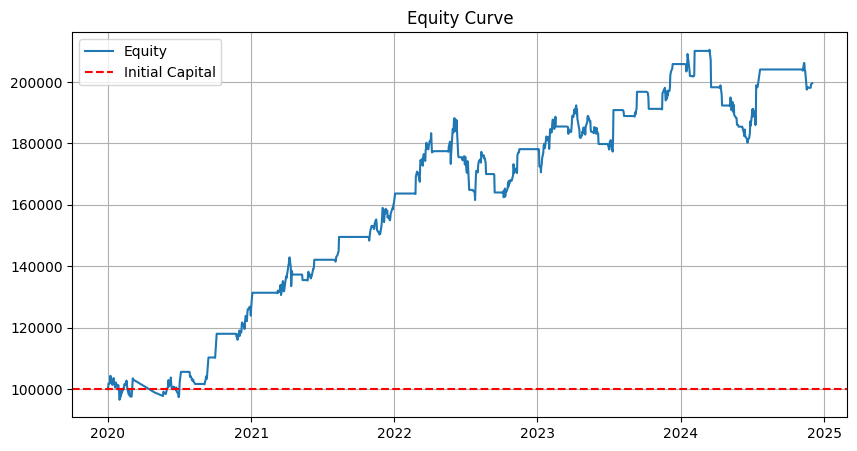

In [12]:
# Plot equity curve
backtester.plot_equity_curve()

In [13]:
# Compare with buy-and-hold
buy_hold_return = (data['Close'].iloc[-1] - data['Close'].iloc[0]) / data['Close'].iloc[0]
print(f'Buy-and-Hold Return: {buy_hold_return:.2%}')
print(f'Strategy Return: {results["total_return"]:.2%}')
print(f'Outperformance: {(results["total_return"] - buy_hold_return):.2%}')

Buy-and-Hold Return: 117.52%
Strategy Return: 99.61%
Outperformance: -17.91%
